In [1]:
import getdist
import matplotlib.pyplot as plt
from getdist import loadMCSamples

# Path to the directory and the base name of the chains
# If your files are: chains/my_run/2026-04-02_4000000__1.txt, etc.
file_root = '/home/jthybo/connect_public/resources/montepython_public/chains/SIDR_interacting_and_std_T_5_4mio/2026-04-02_4000000_'

# Load with 'chain_indices' or just the root; 
# GetDist will find all files matching that root.
samples = loadMCSamples(file_root, settings={'ignore_rows': 0.3})


In [5]:
import numpy as np
from getdist import loadMCSamples

# ---- Load chains ----
file_root = '/home/jthybo/connect_public/resources/montepython_public/chains/SIDR_interacting_and_std_T_5_4mio/2026-04-02_4000000_'
samples = loadMCSamples(file_root, settings={'ignore_rows': 0.3})

chains = samples.getSeparateChains()
param_names = samples.getParamNames().list()

print(f"{'Parameter':<30} | {'R-1':<12}")
print("-" * 45)

max_r_minus_1 = 0.0

for i, name in enumerate(param_names):

    # Extract parameter from each chain
    param_chain = [chain.samples[:, i] for chain in chains]

    # ---- Fix: make equal length ----
    min_len = min(len(c) for c in param_chain)
    param_chain = np.array([c[:min_len] for c in param_chain])

    n = param_chain.shape[1]

    # Means per chain
    chain_means = np.mean(param_chain, axis=1)

    # Variances per chain
    chain_vars = np.var(param_chain, axis=1, ddof=1)

    # Between-chain variance
    B = n * np.var(chain_means, ddof=1)

    # Within-chain variance
    W = np.mean(chain_vars)

    # Variance estimate
    Var_hat = ((n - 1) / n) * W + (1 / n) * B

    # Gelman-Rubin
    R = np.sqrt(Var_hat / W)
    r_minus_1 = R - 1.0

    max_r_minus_1 = max(max_r_minus_1, r_minus_1)

    print(f"{name:<30} | {r_minus_1:.6f}")

print("-" * 45)
print(f"Max Gelman-Rubin (R-1): {max_r_minus_1:.6f}")

Parameter                      | R-1         
---------------------------------------------
omega_b                        | 0.000511
omega_cdm                      | 0.004825
h                              | 0.000424
ln10^{10}A_s                   | 0.003198
n_s                            | 0.002566
tau_reio                       | 0.001202
r                              | 0.001780
m_ncdm_interacting             | 0.001053
log10G_eff_ncdm_interacting    | 0.001108
deg_ncdm_interacting           | 0.004311
m_ncdm_standard                | 0.003867
deg_ncdm_standard              | 0.004792
BBdust                         | 0.000022
BBsync                         | 0.000034
BBalphadust                    | 0.000015
BBbetadust                     | 0.000004
BBalphasync                    | 0.000019
BBbetasync                     | 0.000003
BBdustsynccorr                 | 0.000016
M                              | 0.320761
A_planck                       | 0.000369
H0                        

Max Gelman-Rubin (R-1) across all parameters: 0.780799


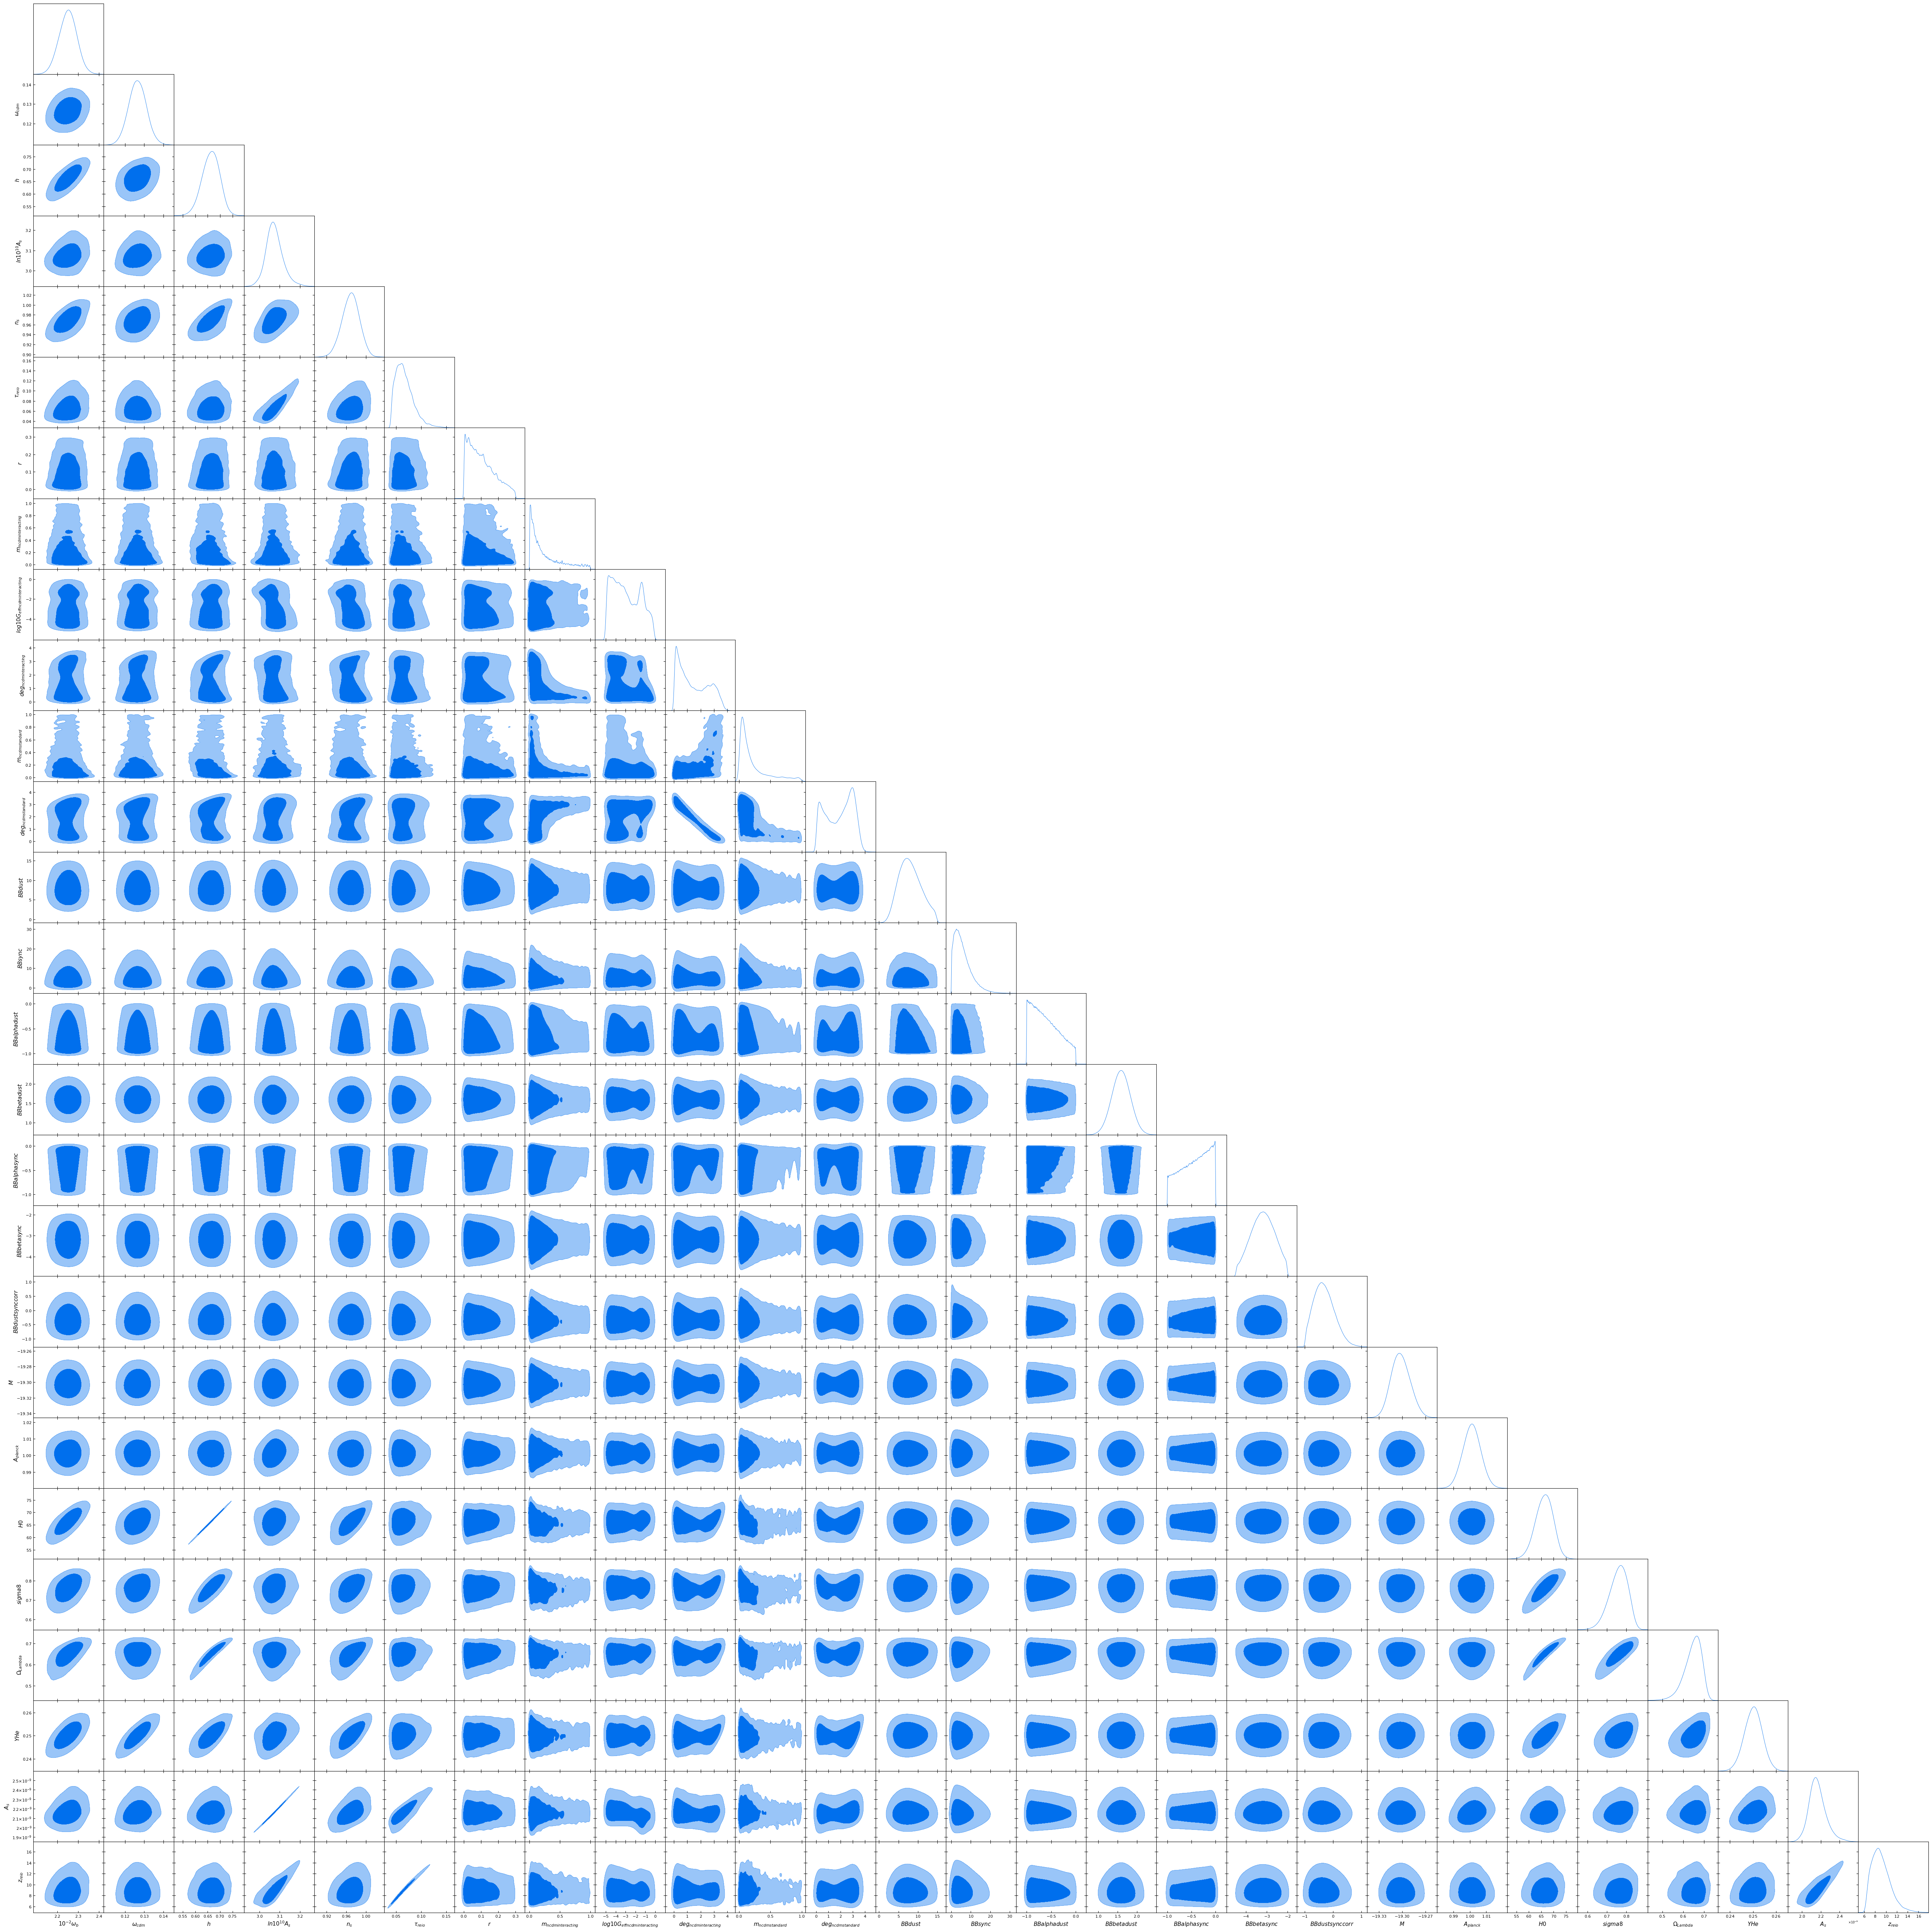

In [6]:
from getdist import loadMCSamples, plots

# ---- 1. Load chains ----
file_root = '/home/jthybo/connect_public/resources/montepython_public/chains/SIDR_interacting_and_std_T_5_4mio/2026-04-02_4000000_'
samples = loadMCSamples(file_root, settings={'ignore_rows': 0.3})

# ---- 2. Print max Gelman-Rubin R-1 ----
max_r_minus_1 = samples.getGelmanRubin()
print(f"Max Gelman-Rubin (R-1) across all parameters: {max_r_minus_1:.6f}")

# ---- 3. Make triangle plot ----
g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True)

# Optional: show plot if running in a notebook
import matplotlib.pyplot as plt
plt.show()